# Market Basket Analysis with Python - Amazon

## Task 1: Data Cleaning and Preparation

### Import Required Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

### Load the Dataset

In [2]:
# Loading the dataset

df = pd.read_csv("Amazon.csv")

df.head()

,Timestamp,age,Gender,Purchase_Frequency,Purchase_Categories,Personalized_Recommendation_Frequency,Browsing_Frequency,Product_Search_Method,Search_Result_Exploration,Customer_Reviews_Importance,...,Review_Left,Review_Reliability,Review_Helpfulness,Personalized_Recommendation_Frequency,Recommendation_Helpfulness,Rating_Accuracy,Shopping_Satisfaction,Service_Appreciation,Improvement_Areas,transaction
0,2023/06/08 7:50:55 PM GMT+5:30,65,Prefer not to say,Less than once a month,Clothing and Fashion,Yes,Multiple times a day,Keyword,Multiple pages,2,...,Yes,Moderately,No,2,Sometimes,4,4,Competitive prices,better app interface and lower shipping charges,778242
1,2023/06/09 9:37:44 AM GMT+5:30,20,Male,Once a week,Groceries and Gourmet Food;Beauty and Personal...,No,Rarely,Filter,First page,3,...,Yes,Heavily,Yes,1,Sometimes,4,5,Quick delivery,Scrolling option would be much better than goi...,193482
2,2023/06/11 11:26:54 PM GMT+5:30,42,Male,Once a week,Groceries and Gourmet Food;Beauty and Personal...,Sometimes,Few times a week,Keyword,Multiple pages,2,...,Yes,Heavily,Sometimes,5,No,5,3,All the above,Nil,925975
3,2023/06/08 5:17:10 PM GMT+5:30,65,Others,Once a month,Beauty and Personal Care;Clothing and Fashion;...,No,Few times a month,Filter,Multiple pages,2,...,Yes,Occasionally,No,3,Yes,1,2,Quick delivery,Quality of product is very poor according to t...,566872
4,2023/06/11 10:59:30 PM GMT+5:30,45,Female,Once a week,Beauty and Personal Care;Clothing and Fashion;...,Sometimes,Few times a month,NaN,First page,5,...,Yes,Rarely,No,2,Yes,1,2,Quick delivery,Irrelevant product suggestions,683642


In [3]:
df.shape

(800, 24)

In [4]:

df.columns

Index(['Timestamp', 'age', 'Gender', 'Purchase_Frequency',
       'Purchase_Categories', 'Personalized_Recommendation_Frequency',
       'Browsing_Frequency', 'Product_Search_Method',
       'Search_Result_Exploration', 'Customer_Reviews_Importance',
       'Add_to_Cart_Browsing', 'Cart_Completion_Frequency',
       'Cart_Abandonment_Factors', 'Saveforlater_Frequency', 'Review_Left',
       'Review_Reliability', 'Review_Helpfulness',
       'Personalized_Recommendation_Frequency ', 'Recommendation_Helpfulness',
       'Rating_Accuracy ', 'Shopping_Satisfaction', 'Service_Appreciation',
       'Improvement_Areas', 'transaction'],
      dtype='str')

In [5]:

df.info()

<class 'pandas.DataFrame'>
RangeIndex: 800 entries, 0 to 799
Data columns (total 24 columns):
 #   Column                                  Non-Null Count  Dtype
---  ------                                  --------------  -----
 0   Timestamp                               800 non-null    str  
 1   age                                     800 non-null    int64
 2   Gender                                  800 non-null    str  
 3   Purchase_Frequency                      800 non-null    str  
 4   Purchase_Categories                     800 non-null    str  
 5   Personalized_Recommendation_Frequency   800 non-null    str  
 6   Browsing_Frequency                      800 non-null    str  
 7   Product_Search_Method                   643 non-null    str  
 8   Search_Result_Exploration               800 non-null    str  
 9   Customer_Reviews_Importance             800 non-null    int64
 10  Add_to_Cart_Browsing                    800 non-null    str  
 11  Cart_Completion_Frequency     

In [6]:

df.describe(include="all")


,Timestamp,age,Gender,Purchase_Frequency,Purchase_Categories,Personalized_Recommendation_Frequency,Browsing_Frequency,Product_Search_Method,Search_Result_Exploration,Customer_Reviews_Importance,...,Review_Left,Review_Reliability,Review_Helpfulness,Personalized_Recommendation_Frequency,Recommendation_Helpfulness,Rating_Accuracy,Shopping_Satisfaction,Service_Appreciation,Improvement_Areas,transaction
count,800,800.000000,800,800,800,800,800,643,800,800.000000,...,800,800,800,800.000000,800,800.000000,800.00000,800,800,800.000000
unique,447,NaN,4,5,29,3,4,4,2,NaN,...,2,5,3,NaN,3,NaN,NaN,9,18,NaN
top,2023/06/08 7:50:55 PM GMT+5:30,NaN,Male,Once a month,Clothing and Fashion;others,Yes,Rarely,Keyword,Multiple pages,NaN,...,No,Heavily,No,NaN,Yes,NaN,NaN,Customer service,User interface,NaN
freq,6,NaN,209,168,39,278,231,170,406,NaN,...,407,167,289,NaN,270,NaN,NaN,109,56,NaN
mean,NaN,35.170000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3.058750,...,NaN,NaN,NaN,2.952500,NaN,2.968750,3.01250,NaN,NaN,556906.991250
std,NaN,18.916485,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.408111,...,NaN,NaN,NaN,1.420481,NaN,1.403651,1.40706,NaN,NaN,261823.943299
min,NaN,3.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.000000,...,NaN,NaN,NaN,1.000000,NaN,1.000000,1.00000,NaN,NaN,101391.000000
25%,NaN,19.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.000000,...,NaN,NaN,NaN,2.000000,NaN,2.000000,2.00000,NaN,NaN,332074.750000
50%,NaN,35.500000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3.000000,...,NaN,NaN,NaN,3.000000,NaN,3.000000,3.00000,NaN,NaN,563278.500000
75%,NaN,51.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4.000000,...,NaN,NaN,NaN,4.000000,NaN,4.000000,4.00000,NaN,NaN,780725.250000


### Check for Duplicate Records

In [7]:
df.duplicated().sum()

np.int64(0)

### Rename Misformatted Columns

In [8]:
df.columns = df.columns.str.strip()

In [9]:
df.columns

Index(['Timestamp', 'age', 'Gender', 'Purchase_Frequency',
       'Purchase_Categories', 'Personalized_Recommendation_Frequency',
       'Browsing_Frequency', 'Product_Search_Method',
       'Search_Result_Exploration', 'Customer_Reviews_Importance',
       'Add_to_Cart_Browsing', 'Cart_Completion_Frequency',
       'Cart_Abandonment_Factors', 'Saveforlater_Frequency', 'Review_Left',
       'Review_Reliability', 'Review_Helpfulness',
       'Personalized_Recommendation_Frequency', 'Recommendation_Helpfulness',
       'Rating_Accuracy', 'Shopping_Satisfaction', 'Service_Appreciation',
       'Improvement_Areas', 'transaction'],
      dtype='str')

### Handle Missing Values

In [10]:

df.isnull().sum()

Timestamp                                  0
age                                        0
Gender                                     0
Purchase_Frequency                         0
Purchase_Categories                        0
Personalized_Recommendation_Frequency      0
Browsing_Frequency                         0
Product_Search_Method                    157
Search_Result_Exploration                  0
Customer_Reviews_Importance                0
Add_to_Cart_Browsing                       0
Cart_Completion_Frequency                  0
Cart_Abandonment_Factors                   0
Saveforlater_Frequency                     0
Review_Left                                0
Review_Reliability                         0
Review_Helpfulness                         0
Personalized_Recommendation_Frequency      0
Recommendation_Helpfulness                 0
Rating_Accuracy                            0
Shopping_Satisfaction                      0
Service_Appreciation                       0
Improvemen

In [11]:
# Display the percentage of missing values

(df.isnull().sum() / len(df)) * 100

Timestamp                                 0.000
age                                       0.000
Gender                                    0.000
Purchase_Frequency                        0.000
Purchase_Categories                       0.000
Personalized_Recommendation_Frequency     0.000
Browsing_Frequency                        0.000
Product_Search_Method                    19.625
Search_Result_Exploration                 0.000
Customer_Reviews_Importance               0.000
Add_to_Cart_Browsing                      0.000
Cart_Completion_Frequency                 0.000
Cart_Abandonment_Factors                  0.000
Saveforlater_Frequency                    0.000
Review_Left                               0.000
Review_Reliability                        0.000
Review_Helpfulness                        0.000
Personalized_Recommendation_Frequency     0.000
Recommendation_Helpfulness                0.000
Rating_Accuracy                           0.000
Shopping_Satisfaction                   

In [12]:

df["Product_Search_Method"].unique()

<ArrowStringArray>
['Keyword', 'Filter', nan, 'others', 'categories']
Length: 5, dtype: str

In [13]:
# Find the most frequent value (mode) in Product_Search_Method

df["Product_Search_Method"].mode()

0    Keyword
Name: Product_Search_Method, dtype: str

In [14]:
# Fill missing values with the mode

df["Product_Search_Method"] = df["Product_Search_Method"].fillna(
    df["Product_Search_Method"].mode()[0]
)

In [15]:

df["Product_Search_Method"].isnull().sum()

np.int64(0)

### Rename Duplicate and Misformatted Column Names

In [16]:
for i, col in enumerate(df.columns):
    print(i, ":", col)

0 : Timestamp
1 : age
2 : Gender
3 : Purchase_Frequency
4 : Purchase_Categories
5 : Personalized_Recommendation_Frequency
6 : Browsing_Frequency
7 : Product_Search_Method
8 : Search_Result_Exploration
9 : Customer_Reviews_Importance
10 : Add_to_Cart_Browsing
11 : Cart_Completion_Frequency
12 : Cart_Abandonment_Factors
13 : Saveforlater_Frequency
14 : Review_Left
15 : Review_Reliability
16 : Review_Helpfulness
17 : Personalized_Recommendation_Frequency
18 : Recommendation_Helpfulness
19 : Rating_Accuracy
20 : Shopping_Satisfaction
21 : Service_Appreciation
22 : Improvement_Areas
23 : transaction


In [17]:
# Rename duplicate column names

df.columns = [
    "Timestamp",
    "age",
    "Gender",
    "Purchase_Frequency",
    "Purchase_Categories",
    "Personalized_Recommendation_Response",
    "Browsing_Frequency",
    "Product_Search_Method",
    "Search_Result_Exploration",
    "Customer_Reviews_Importance",
    "Add_to_Cart_Browsing",
    "Cart_Completion_Frequency",
    "Cart_Abandonment_Factors",
    "Saveforlater_Frequency",
    "Review_Left",
    "Review_Reliability",
    "Review_Helpfulness",
    "Personalized_Recommendation_Rating",
    "Recommendation_Helpfulness",
    "Rating_Accuracy",
    "Shopping_Satisfaction",
    "Service_Appreciation",
    "Improvement_Areas",
    "transaction"
]

In [18]:

df.columns

Index(['Timestamp', 'age', 'Gender', 'Purchase_Frequency',
       'Purchase_Categories', 'Personalized_Recommendation_Response',
       'Browsing_Frequency', 'Product_Search_Method',
       'Search_Result_Exploration', 'Customer_Reviews_Importance',
       'Add_to_Cart_Browsing', 'Cart_Completion_Frequency',
       'Cart_Abandonment_Factors', 'Saveforlater_Frequency', 'Review_Left',
       'Review_Reliability', 'Review_Helpfulness',
       'Personalized_Recommendation_Rating', 'Recommendation_Helpfulness',
       'Rating_Accuracy', 'Shopping_Satisfaction', 'Service_Appreciation',
       'Improvement_Areas', 'transaction'],
      dtype='str')

### Standardize Categorical Entries

In [19]:
categorical_columns = df.select_dtypes(include='object').columns

for col in categorical_columns:
    print(f"\n{col}")
    print(df[col].unique())
    
    


Timestamp
<ArrowStringArray>
[ '2023/06/08 7:50:55 PM GMT+5:30',  '2023/06/09 9:37:44 AM GMT+5:30',
 '2023/06/11 11:26:54 PM GMT+5:30',  '2023/06/08 5:17:10 PM GMT+5:30',
 '2023/06/11 10:59:30 PM GMT+5:30',  '2023/06/07 9:18:55 PM GMT+5:30',
  '2023/06/08 7:46:31 PM GMT+5:30',  '2023/06/06 7:02:21 PM GMT+5:30',
 '2023/06/07 11:07:55 PM GMT+5:30',  '2023/06/05 4:50:44 PM GMT+5:30',
 ...
 '2023/06/05 10:09:03 PM GMT+5:30',  '2023/06/07 9:17:50 PM GMT+5:30',
  '2023/06/09 4:32:00 PM GMT+5:30',  '2023/06/04 9:10:51 PM GMT+5:30',
  '2023/06/09 4:29:50 PM GMT+5:30',  '2023/06/07 3:56:01 PM GMT+5:30',
  '2023/06/08 9:40:24 PM GMT+5:30',  '2023/06/08 5:53:11 PM GMT+5:30',
  '2023/06/09 3:00:03 PM GMT+5:30', '2023/06/11 11:25:48 PM GMT+5:30']
Length: 447, dtype: str

Gender
<ArrowStringArray>
['Prefer not to say', 'Male', 'Others', 'Female']
Length: 4, dtype: str

Purchase_Frequency
<ArrowStringArray>
['Less than once a month',            'Once a week',           'Once a month',
      'Few tim

C:\Users\SUHANI\AppData\Local\Temp\ipykernel_12260\994383131.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_columns = df.select_dtypes(include='object').columns


In [20]:
# Remove leading and trailing spaces from all categorical columns

categorical_columns = df.select_dtypes(include=['object', 'string']).columns

for col in categorical_columns:
    df[col] = df[col].str.strip()

In [21]:
for col in categorical_columns:
    print(f"\n{col}")
    print(df[col].unique())


Timestamp
<ArrowStringArray>
[ '2023/06/08 7:50:55 PM GMT+5:30',  '2023/06/09 9:37:44 AM GMT+5:30',
 '2023/06/11 11:26:54 PM GMT+5:30',  '2023/06/08 5:17:10 PM GMT+5:30',
 '2023/06/11 10:59:30 PM GMT+5:30',  '2023/06/07 9:18:55 PM GMT+5:30',
  '2023/06/08 7:46:31 PM GMT+5:30',  '2023/06/06 7:02:21 PM GMT+5:30',
 '2023/06/07 11:07:55 PM GMT+5:30',  '2023/06/05 4:50:44 PM GMT+5:30',
 ...
 '2023/06/05 10:09:03 PM GMT+5:30',  '2023/06/07 9:17:50 PM GMT+5:30',
  '2023/06/09 4:32:00 PM GMT+5:30',  '2023/06/04 9:10:51 PM GMT+5:30',
  '2023/06/09 4:29:50 PM GMT+5:30',  '2023/06/07 3:56:01 PM GMT+5:30',
  '2023/06/08 9:40:24 PM GMT+5:30',  '2023/06/08 5:53:11 PM GMT+5:30',
  '2023/06/09 3:00:03 PM GMT+5:30', '2023/06/11 11:25:48 PM GMT+5:30']
Length: 447, dtype: str

Gender
<ArrowStringArray>
['Prefer not to say', 'Male', 'Others', 'Female']
Length: 4, dtype: str

Purchase_Frequency
<ArrowStringArray>
['Less than once a month',            'Once a week',           'Once a month',
      'Few tim

### Convert Rating Columns to Numeric Data Types

In [22]:
rating_columns = [
    "Customer_Reviews_Importance",
    "Personalized_Recommendation_Rating",
    "Rating_Accuracy",
    "Shopping_Satisfaction"
]

for col in rating_columns:
    df[col] = pd.to_numeric(df[col])

In [23]:
df[rating_columns].dtypes

Customer_Reviews_Importance           int64
Personalized_Recommendation_Rating    int64
Rating_Accuracy                       int64
Shopping_Satisfaction                 int64
dtype: object

## Task 2: Descriptive Behavior Analysis

### Customer Demographics Analysis

#### Age Distribution

In [24]:

df["age"].describe()

count    800.000000
mean      35.170000
std       18.916485
min        3.000000
25%       19.000000
50%       35.500000
75%       51.000000
max       67.000000
Name: age, dtype: float64

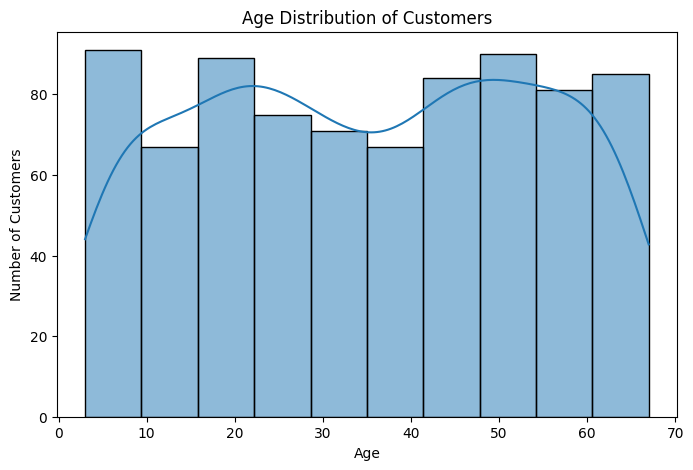

In [30]:

plt.figure(figsize=(8,5))
sns.histplot(df["age"], bins=10, kde=True)

plt.title("Age Distribution of Customers")
plt.xlabel("Age")
plt.ylabel("Number of Customers")

plt.savefig("Images/age_distribution.png", dpi=300, bbox_inches="tight")

plt.show()

#### Gender Distribution

In [26]:
df["Gender"].value_counts()

Gender
Male                 209
Others               202
Female               197
Prefer not to say    192
Name: count, dtype: int64

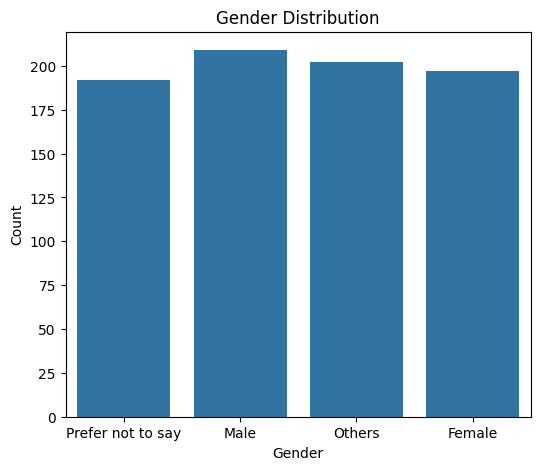

In [31]:

plt.figure(figsize=(6,5))
sns.countplot(x="Gender", data=df)

plt.title("Gender Distribution")
plt.xlabel("Gender")
plt.ylabel("Count")

plt.savefig("Images/gender_distribution.png", dpi=300, bbox_inches="tight")

plt.show()

##### Observation

- Male respondents represent the largest group (209 customers).
- The distribution is fairly balanced across all four gender categories.
- "Prefer not to say" has the lowest number of responses (192 customers).

### Purchase Frequency Analysis

In [33]:
df["Purchase_Frequency"].value_counts()

Purchase_Frequency
Once a month              168
Once a week               159
Multiple times a week     159
Few times a month         158
Less than once a month    156
Name: count, dtype: int64

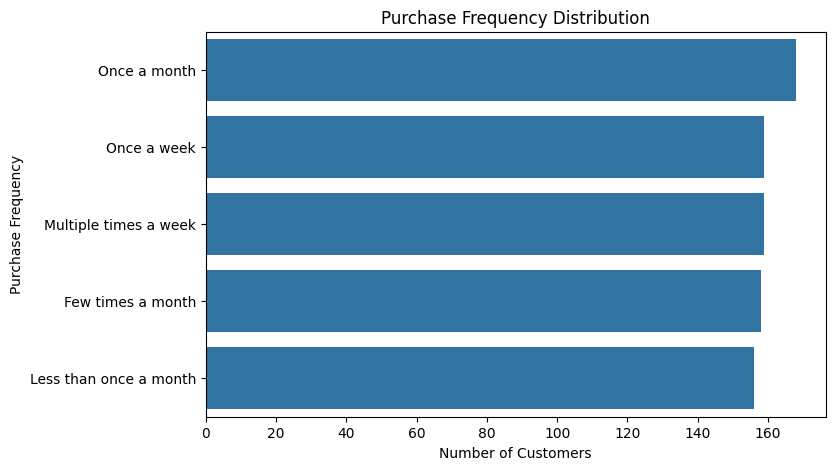

In [34]:
plt.figure(figsize=(8,5))
sns.countplot(
    y="Purchase_Frequency",
    data=df,
    order=df["Purchase_Frequency"].value_counts().index
)

plt.title("Purchase Frequency Distribution")
plt.xlabel("Number of Customers")
plt.ylabel("Purchase Frequency")

plt.savefig("Images/purchase_frequency_distribution.png", dpi=300, bbox_inches="tight")

plt.show()

##### Observation

- "Once a month" is the most common purchase frequency (168 customers).
- The five purchase frequency categories are distributed quite evenly.
- This suggests a diverse customer shopping pattern.

### Most Popular Product Categories

In [35]:
df["Purchase_Categories"].head(10)

0                                 Clothing and Fashion
1    Groceries and Gourmet Food;Beauty and Personal...
2    Groceries and Gourmet Food;Beauty and Personal...
3    Beauty and Personal Care;Clothing and Fashion;...
4    Beauty and Personal Care;Clothing and Fashion;...
5    Groceries and Gourmet Food;Clothing and Fashio...
6    Groceries and Gourmet Food;Beauty and Personal...
7        Beauty and Personal Care;Clothing and Fashion
8                      Beauty and Personal Care;others
9                Clothing and Fashion;Home and Kitchen
Name: Purchase_Categories, dtype: str

In [36]:
categories = (
    df["Purchase_Categories"]
    .str.split(";")
    .explode()
    .str.strip()
)

In [37]:
category_counts = categories.value_counts()

category_counts

Purchase_Categories
Clothing and Fashion          450
others                        412
Home and Kitchen              391
Beauty and Personal Care      383
Groceries and Gourmet Food    369
Name: count, dtype: int64

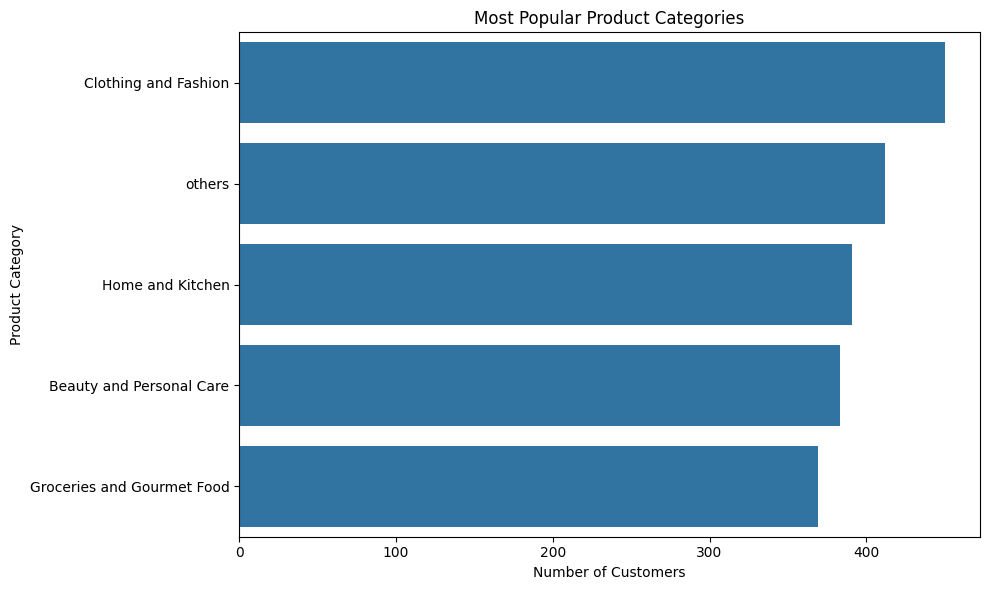

In [38]:
plt.figure(figsize=(10,6))

sns.barplot(
    x=category_counts.values,
    y=category_counts.index
)

plt.title("Most Popular Product Categories")
plt.xlabel("Number of Customers")
plt.ylabel("Product Category")

plt.tight_layout()

# Save the chart
plt.savefig("Images/most_popular_product_categories.png", dpi=300, bbox_inches="tight")

plt.show()

##### Observation

- Clothing and Fashion is the most popular product category with **450** customer selections.
- The **others** category is the second most selected with **412** responses.
- Home and Kitchen (**391**), Beauty and Personal Care (**383**), and Groceries and Gourmet Food (**369**) also show high customer interest.
- Overall, Clothing and Fashion is the most preferred shopping category among the surveyed Amazon customers.

### Product Search Methods

In [39]:
df["Product_Search_Method"].value_counts()

Product_Search_Method
Keyword       327
categories    163
Filter        161
others        149
Name: count, dtype: int64

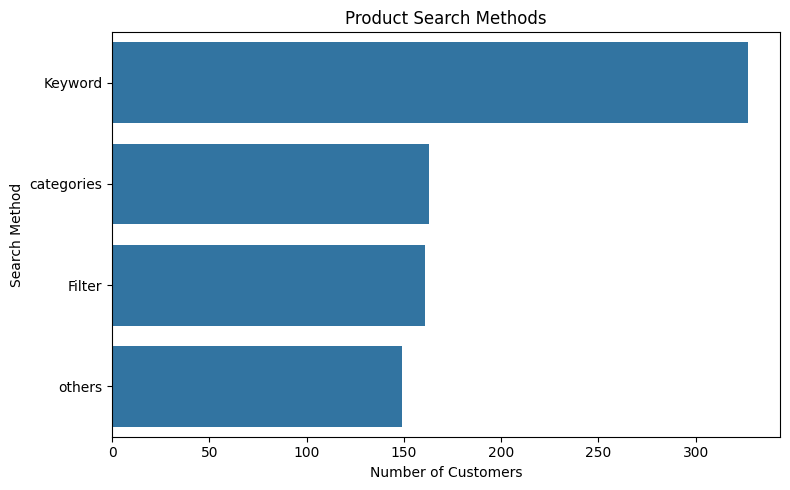

In [40]:

plt.figure(figsize=(8,5))

sns.countplot(
    y="Product_Search_Method",
    data=df,
    order=df["Product_Search_Method"].value_counts().index
)

plt.title("Product Search Methods")
plt.xlabel("Number of Customers")
plt.ylabel("Search Method")

plt.tight_layout()

# Save the chart
plt.savefig("Images/product_search_methods.png",
            dpi=300,
            bbox_inches="tight")

plt.show()

##### Observation
- Keyword is the most commonly used product search method with 327 customers.
- Categories is the second most preferred search method with 163 customers.
- Filter and Others are used by 161 and 149 customers respectively.
- This indicates that most customers prefer searching products using keywords rather than browsing through categories or filters.

### Cart Abandonment Factors

In [41]:
df["Cart_Abandonment_Factors"].value_counts()

Cart_Abandonment_Factors
High shipping costs                           224
Found a better price elsewhere                206
Changed my mind or no longer need the item    194
others                                        176
Name: count, dtype: int64

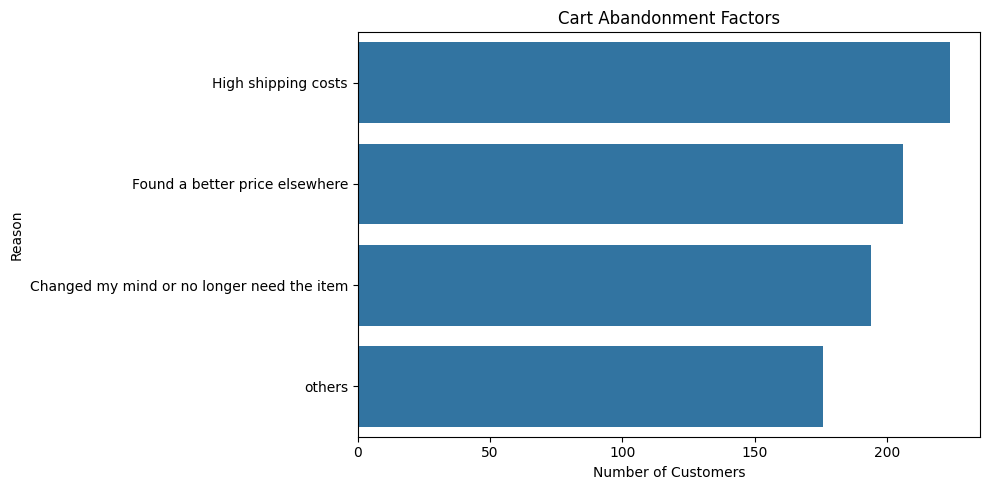

In [42]:

plt.figure(figsize=(10,5))

sns.countplot(
    y="Cart_Abandonment_Factors",
    data=df,
    order=df["Cart_Abandonment_Factors"].value_counts().index
)

plt.title("Cart Abandonment Factors")
plt.xlabel("Number of Customers")
plt.ylabel("Reason")

plt.tight_layout()

# Save the chart
plt.savefig("Images/cart_abandonment_factors.png",
            dpi=300,
            bbox_inches="tight")

plt.show()

##### Observation
- High shipping costs are the leading reason for cart abandonment with 224 responses.
- Found a better price elsewhere is the second most common reason with 206 responses.
- Changed my mind or no longer need the item accounts for 194 responses.
- Other reasons contribute 176 responses.
- Shipping cost appears to be the major factor influencing customers to abandon their shopping carts.

### Mean and Median Analysis

In [43]:

analysis = pd.DataFrame({
    "Mean": [
        df["Shopping_Satisfaction"].mean(),
        df["Rating_Accuracy"].mean(),
        df["Personalized_Recommendation_Rating"].mean()
    ],
    "Median": [
        df["Shopping_Satisfaction"].median(),
        df["Rating_Accuracy"].median(),
        df["Personalized_Recommendation_Rating"].median()
    ]
},
index=[
    "Shopping Satisfaction",
    "Rating Accuracy",
    "Personalized Recommendation Rating"
])

analysis

,Mean,Median
Shopping Satisfaction,3.01250,3.0
Rating Accuracy,2.96875,3.0
Personalized Recommendation Rating,2.95250,3.0


##### Observation
- The mean Shopping Satisfaction score is 3.01, with a median of 3.
- The mean Rating Accuracy score is 2.97, with a median of 3.
- The mean Personalized Recommendation Rating is 2.95, with a median of 3.
- The mean and median values are very close, indicating that customer responses are centered around a neutral to moderately positive rating.

### Summary Statistics

In [44]:

numerical_columns = [
    "age",
    "Customer_Reviews_Importance",
    "Personalized_Recommendation_Rating",
    "Rating_Accuracy",
    "Shopping_Satisfaction"
]

df[numerical_columns].describe()

,age,Customer_Reviews_Importance,Personalized_Recommendation_Rating,Rating_Accuracy,Shopping_Satisfaction
count,800.000000,800.000000,800.000000,800.000000,800.00000
mean,35.170000,3.058750,2.952500,2.968750,3.01250
std,18.916485,1.408111,1.420481,1.403651,1.40706
min,3.000000,1.000000,1.000000,1.000000,1.00000
25%,19.000000,2.000000,2.000000,2.000000,2.00000
50%,35.500000,3.000000,3.000000,3.000000,3.00000
75%,51.000000,4.000000,4.000000,4.000000,4.00000
max,67.000000,5.000000,5.000000,5.000000,5.00000


##### Observation
- The dataset contains 800 customer responses.
- Customer ages range from 3 to 67 years, with an average age of approximately 35 years.
- The average scores for Customer Reviews Importance, Personalized Recommendation Rating, Rating Accuracy, and Shopping Satisfaction are close to 3.
- Overall, the numerical variables indicate moderate customer perceptions and satisfaction levels.

## Task 3: Customer Segmentation and Profiling

### Analyze Purchase Frequency and Shopping Satisfaction

In [45]:
df["Purchase_Frequency"].value_counts()

Purchase_Frequency
Once a month              168
Once a week               159
Multiple times a week     159
Few times a month         158
Less than once a month    156
Name: count, dtype: int64

In [46]:
df["Shopping_Satisfaction"].value_counts().sort_index()

Shopping_Satisfaction
1    152
2    168
3    160
4    158
5    162
Name: count, dtype: int64

In [47]:
pd.crosstab(
    df["Purchase_Frequency"],
    df["Shopping_Satisfaction"]
)

Shopping_Satisfaction,1,2,3,4,5
Purchase_Frequency,,,,,
Few times a month,38,38,32,28,22
Less than once a month,26,38,23,33,36
Multiple times a week,19,28,37,35,40
Once a month,34,37,31,31,35
Once a week,35,27,37,31,29


### Create Customer Profiles

In [48]:


def customer_segment(row):

    if row["Purchase_Frequency"] == "Multiple times a week":
        return "Frequent Buyers"

    elif row["Purchase_Frequency"] in [
        "Few times a month",
        "Once a month",
        "Once a week"
    ]:
        return "Occasional Shoppers"

    else:
        return "At-Risk Customers"


df["Customer_Segment"] = df.apply(customer_segment, axis=1)

In [49]:
df["Customer_Segment"].value_counts()

Customer_Segment
Occasional Shoppers    485
Frequent Buyers        159
At-Risk Customers      156
Name: count, dtype: int64

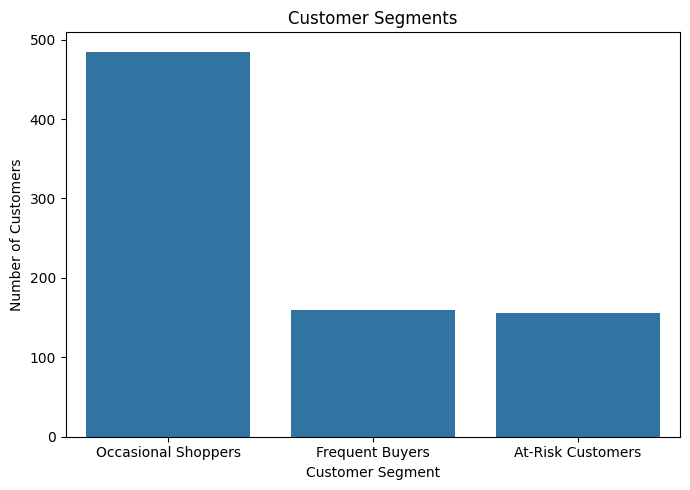

In [50]:
plt.figure(figsize=(7,5))

sns.countplot(
    x="Customer_Segment",
    data=df,
    order=df["Customer_Segment"].value_counts().index
)

plt.title("Customer Segments")
plt.xlabel("Customer Segment")
plt.ylabel("Number of Customers")

plt.tight_layout()

plt.savefig("Images/customer_segments.png", dpi=300, bbox_inches="tight")

plt.show()

##### Observation
- Occasional Shoppers form the largest customer segment with 485 customers.
- Frequent Buyers account for 159 customers.
- At-Risk Customers account for 156 customers.
- Most customers purchase products occasionally, indicating moderate purchasing behavior.

### Demographic Analysis of Customer Segments

In [51]:
pd.crosstab(
    df["Customer_Segment"],
    df["Gender"]
)

Gender,Female,Male,Others,Prefer not to say
Customer_Segment,,,,
At-Risk Customers,35,47,30,44
Frequent Buyers,31,46,48,34
Occasional Shoppers,131,116,124,114


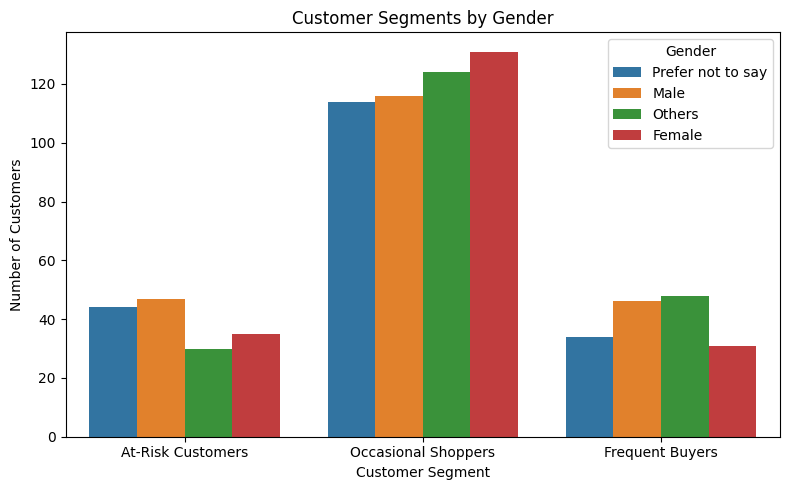

In [52]:


plt.figure(figsize=(8,5))

sns.countplot(
    x="Customer_Segment",
    hue="Gender",
    data=df
)

plt.title("Customer Segments by Gender")
plt.xlabel("Customer Segment")
plt.ylabel("Number of Customers")

plt.tight_layout()

plt.savefig("Images/customer_segments_by_gender.png", dpi=300, bbox_inches="tight")

plt.show()

##### Observation
- Occasional Shoppers represent the largest customer segment across all gender categories.
- Male customers form the highest number of Frequent Buyers (46).
- Female customers account for the highest number of Occasional Shoppers (131).
- The At-Risk Customer segment is relatively balanced across all gender categories.

### K-Means Clustering

In [53]:
from sklearn.cluster import KMeans

In [54]:

X = df[
    [
        "Shopping_Satisfaction",
        "Customer_Reviews_Importance",
        "Rating_Accuracy",
        "Personalized_Recommendation_Rating"
    ]
]

In [55]:

kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)

df["Cluster"] = kmeans.fit_predict(X)

In [56]:
df["Cluster"].value_counts()

Cluster
0    302
1    258
2    240
Name: count, dtype: int64

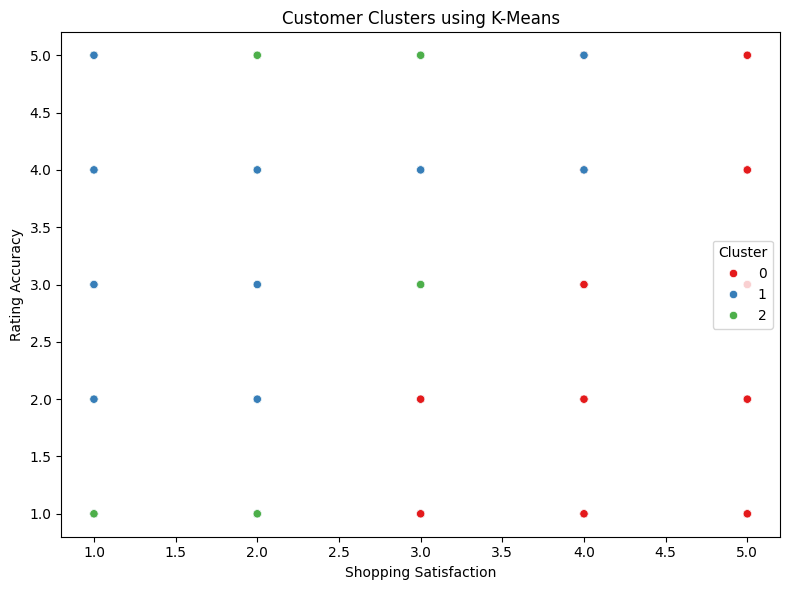

In [58]:

plt.figure(figsize=(8,6))

sns.scatterplot(x="Shopping_Satisfaction",y="Rating_Accuracy",hue="Cluster",palette="Set1",data=df)

plt.title("Customer Clusters using K-Means")
plt.xlabel("Shopping Satisfaction")
plt.ylabel("Rating Accuracy")

plt.tight_layout()

plt.savefig("Images/kmeans_clusters.png", dpi=300, bbox_inches="tight")

plt.show()

##### Observation
- The K-Means algorithm grouped the customers into three clusters.
- Cluster 0 contains 302 customers.
- Cluster 1 contains 258 customers.
- Cluster 2 contains 240 customers.
- The clusters represent different customer behavior patterns based on shopping satisfaction, review importance, rating accuracy, and personalized recommendation rating.

## Task 4: Recommendation and Review Insights

###  Recommendation Helpfulness and Shopping Satisfaction

In [59]:
pd.crosstab(
    df["Recommendation_Helpfulness"],
    df["Shopping_Satisfaction"]
)

Shopping_Satisfaction,1,2,3,4,5
Recommendation_Helpfulness,,,,,
No,49,52,52,57,52
Sometimes,57,55,52,51,53
Yes,46,61,56,50,57


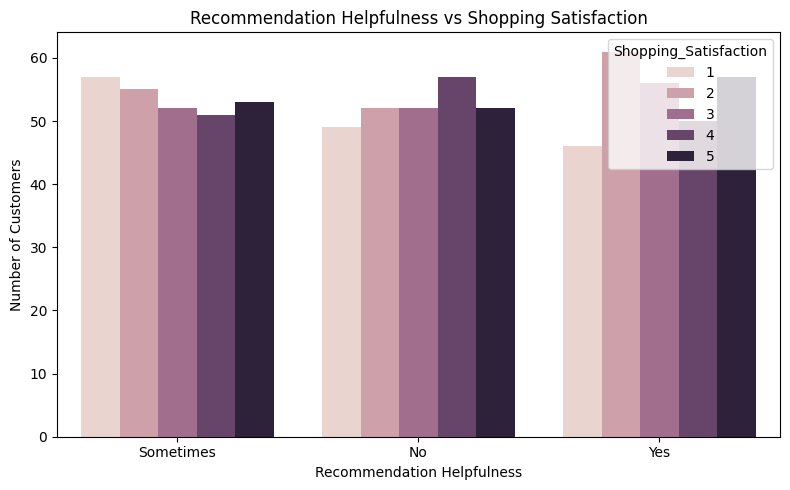

In [60]:

plt.figure(figsize=(8,5))

sns.countplot(x="Recommendation_Helpfulness",hue="Shopping_Satisfaction",data=df)

plt.title("Recommendation Helpfulness vs Shopping Satisfaction")
plt.xlabel("Recommendation Helpfulness")
plt.ylabel("Number of Customers")

plt.tight_layout()

plt.savefig("Images/recommendation_helpfulness_vs_satisfaction.png",dpi=300,bbox_inches="tight")

plt.show()

##### Observation
- Recommendation helpfulness responses are fairly evenly distributed across all shopping satisfaction levels.
- Customers who selected "Yes", "Sometimes", and "No" all reported satisfaction ratings ranging from 1 to 5.
- No single recommendation helpfulness category shows a strong dominance for any particular satisfaction level.
- This indicates that recommendation helpfulness alone does not strongly influence overall shopping satisfaction.

### Review Reliability and Review Helpfulness

In [61]:

df["Review_Reliability"].value_counts()

Review_Reliability
Heavily         167
Never           166
Occasionally    161
Moderately      156
Rarely          150
Name: count, dtype: int64

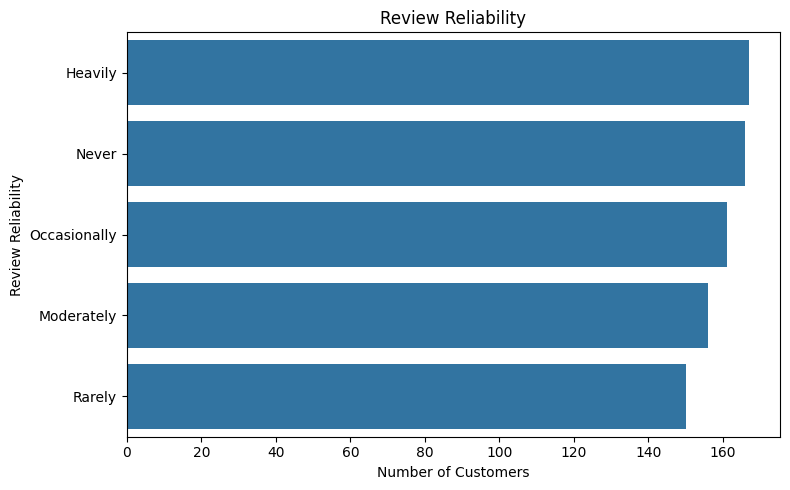

In [63]:
plt.figure(figsize=(8,5))

sns.countplot(y="Review_Reliability",data=df,order=df["Review_Reliability"].value_counts().index)

plt.title("Review Reliability")
plt.xlabel("Number of Customers")
plt.ylabel("Review Reliability")

plt.tight_layout()

plt.savefig("Images/review_reliability.png",dpi=300,bbox_inches="tight")

plt.show()

##### Observation
- "Heavily" is the most common review reliability response with 167 customers.
- "Never" is the second most common response with 166 customers.
- "Occasionally", "Moderately", and "Rarely" have similar response counts.
- Customer opinions regarding review reliability are fairly evenly distributed.

In [65]:

df["Review_Helpfulness"].value_counts()

Review_Helpfulness
No           289
Yes          257
Sometimes    254
Name: count, dtype: int64

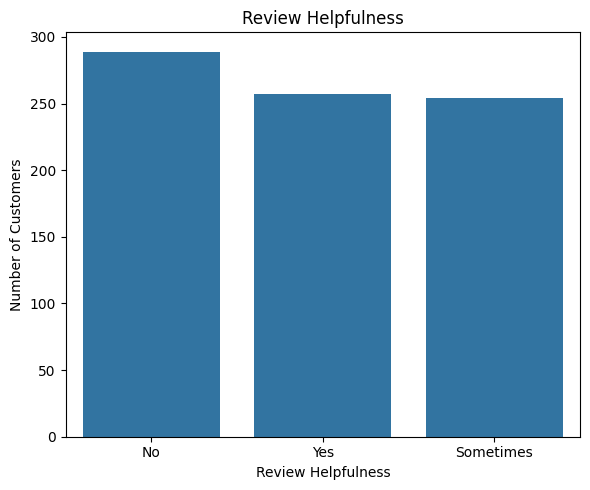

In [64]:
plt.figure(figsize=(6,5))

sns.countplot(x="Review_Helpfulness",data=df,order=df["Review_Helpfulness"].value_counts().index)

plt.title("Review Helpfulness")
plt.xlabel("Review Helpfulness")
plt.ylabel("Number of Customers")

plt.tight_layout()

plt.savefig("Images/review_helpfulness.png",dpi=300,bbox_inches="tight")

plt.show()

##### Observation
- "No" is the most common response for review helpfulness with 289 customers.
- "Yes" and "Sometimes" have similar response counts of 257 and 254 respectively.
- Customer opinions on review helpfulness are relatively balanced across the three categories.

### Personalized Recommendation Analysis

In [66]:
df["Personalized_Recommendation_Response"].value_counts()

Personalized_Recommendation_Response
Yes          278
No           272
Sometimes    250
Name: count, dtype: int64

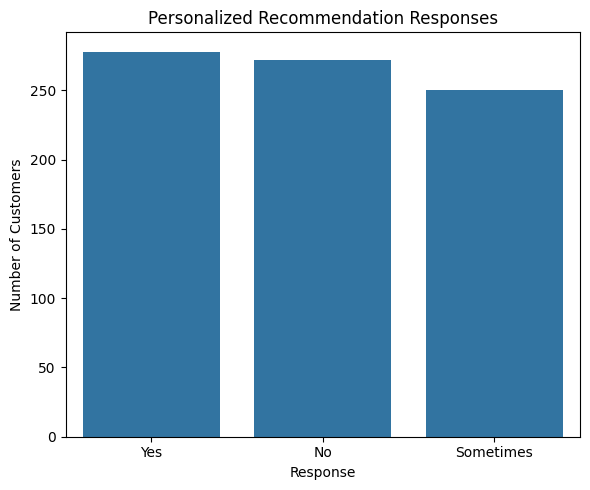

In [67]:

plt.figure(figsize=(6,5))

sns.countplot(x="Personalized_Recommendation_Response",data=df,order=df["Personalized_Recommendation_Response"].value_counts().index)

plt.title("Personalized Recommendation Responses")
plt.xlabel("Response")
plt.ylabel("Number of Customers")

plt.tight_layout()

plt.savefig("Images/personalized_recommendation_responses.png",dpi=300,bbox_inches="tight")

plt.show()

##### Observation
- "Yes" is the most common response for personalized recommendations with 278 customers.
- "No" follows closely with 272 customers.
- "Sometimes" was selected by 250 customers.
- Customer responses indicate a relatively balanced perception of personalized recommendations.

### Actionable Insights

In [69]:
df["Service_Appreciation"].value_counts()

Service_Appreciation
Customer service                       181
Quick delivery                         104
All the above                           92
Wide product selection                  91
Competitive prices                      90
.                                       88
User-friendly website/app interface     81
Product recommendations                 73
Name: count, dtype: int64

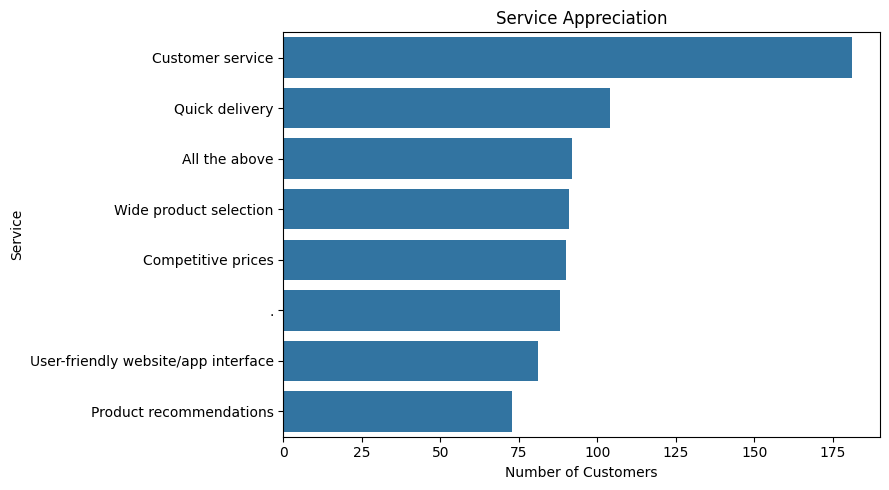

In [71]:
plt.figure(figsize=(9,5))

sns.countplot(y="Service_Appreciation",data=df,order=df["Service_Appreciation"].value_counts().index)

plt.title("Service Appreciation")
plt.xlabel("Number of Customers")
plt.ylabel("Service")

plt.tight_layout()

plt.savefig("Images/service_appreciation.png",dpi=300,bbox_inches="tight")

plt.show()

##### Observation
- Customer service is the most appreciated service with 181 responses.
- Quick delivery is the second most appreciated service with 104 responses.
- Wide product selection, competitive prices, and user-friendly website/app interface are also valued by customers.
- Overall, customer service and quick delivery are the key strengths appreciated by customers.

In [73]:
df["Improvement_Areas"].value_counts()

Improvement_Areas
User interface                                                                   56
I don't have any problem with Amazon                                             53
Product quality and accuracy                                                     53
I have no problem with Amazon yet. But others tell me about the refund issues    51
Quality of product is very poor according to the big offers                      49
User interface of app                                                            49
Shipping speed and reliability                                                   46
No problems with Amazon                                                          45
Customer service responsiveness                                                  44
.                                                                                44
Irrelevant product suggestions                                                   43
Nothing                                                   

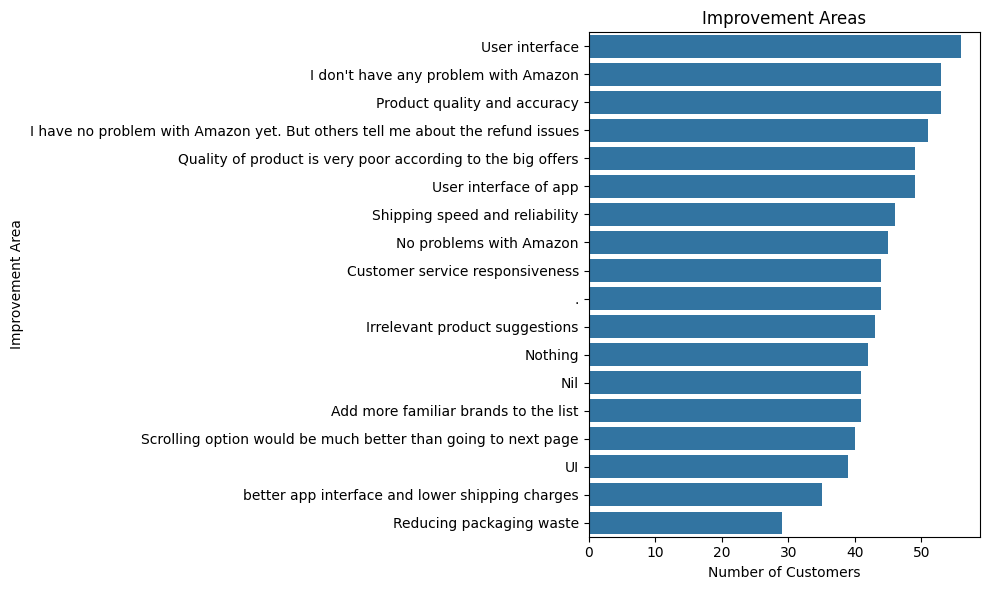

In [72]:

plt.figure(figsize=(10,6))

sns.countplot(y="Improvement_Areas",data=df,order=df["Improvement_Areas"].value_counts().index)

plt.title("Improvement Areas")
plt.xlabel("Number of Customers")
plt.ylabel("Improvement Area")

plt.tight_layout()

plt.savefig("Images/improvement_areas.png",dpi=300,bbox_inches="tight")

plt.show()

##### Observation
- User Interface is the most frequently suggested improvement area with 56 responses.
- Product quality and accuracy, refund issues, and product quality during large offers are also common concerns.
- Shipping speed, customer service responsiveness, and product recommendations were identified as additional areas for improvement.
- Although many customers reported no problems, several improvement opportunities were identified from customer feedback.

## Task 5: Visualization and Reporting

### Purchase Categories Visualization

In [86]:

purchase_categories = (
    df["Purchase_Categories"]
    .str.split(";")
    .explode()
    .value_counts()
)

purchase_categories

Purchase_Categories
Clothing and Fashion          450
others                        412
Home and Kitchen              391
Beauty and Personal Care      383
Groceries and Gourmet Food    369
Name: count, dtype: int64

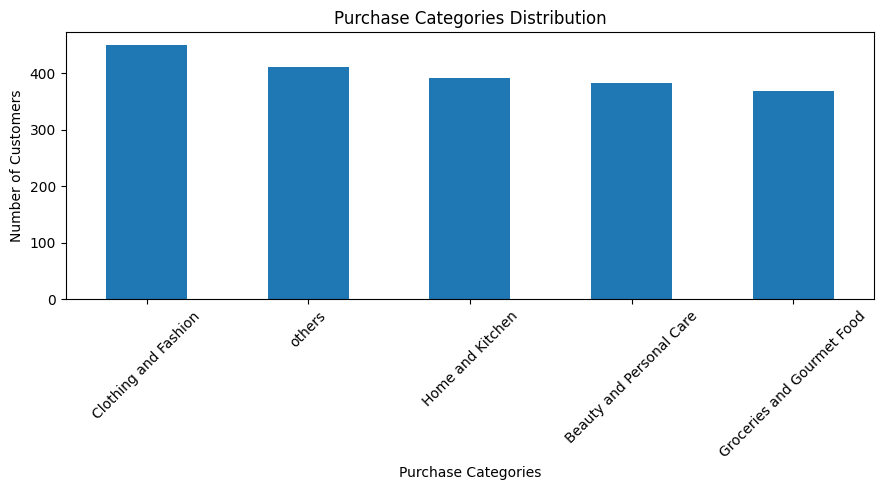

In [87]:
plt.figure(figsize=(9,5))

purchase_categories.plot(kind="bar")

plt.title("Purchase Categories Distribution")
plt.xlabel("Purchase Categories")
plt.ylabel("Number of Customers")

plt.xticks(rotation=45)

plt.tight_layout()

plt.savefig(
    "Images/purchase_categories_bar_chart.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

##### Observation
- Clothing and Fashion is the most frequently purchased category.
- Home and Kitchen, Others, Beauty and Personal Care, and Groceries and Gourmet Food are also popular purchase categories.
- Customers commonly purchase products across multiple categories.

### Browsing Frequency Distribution

In [88]:
df["Browsing_Frequency"].value_counts()

Browsing_Frequency
Rarely                  231
Few times a month       200
Few times a week        186
Multiple times a day    183
Name: count, dtype: int64

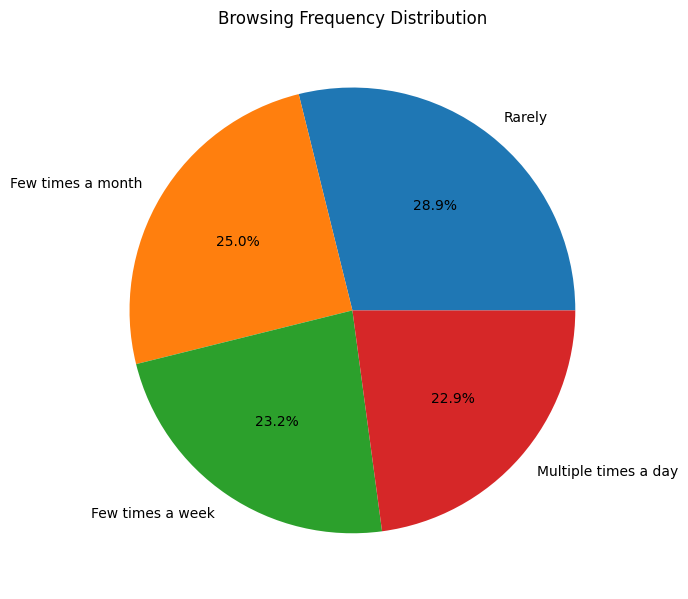

In [89]:
plt.figure(figsize=(7,7))

df["Browsing_Frequency"].value_counts().plot(
    kind="pie",
    autopct="%1.1f%%"
)

plt.ylabel("")

plt.title("Browsing Frequency Distribution")

plt.tight_layout()

plt.savefig(
    "Images/browsing_frequency_pie_chart.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

##### Observation
- Customers browse products at different frequencies.
- Rarely and few times a month are among the common browsing patterns.
- Browsing behavior varies considerably across customers.

### Shopping Satisfaction Levels

In [90]:
df["Shopping_Satisfaction"].value_counts().sort_index()

Shopping_Satisfaction
1    152
2    168
3    160
4    158
5    162
Name: count, dtype: int64

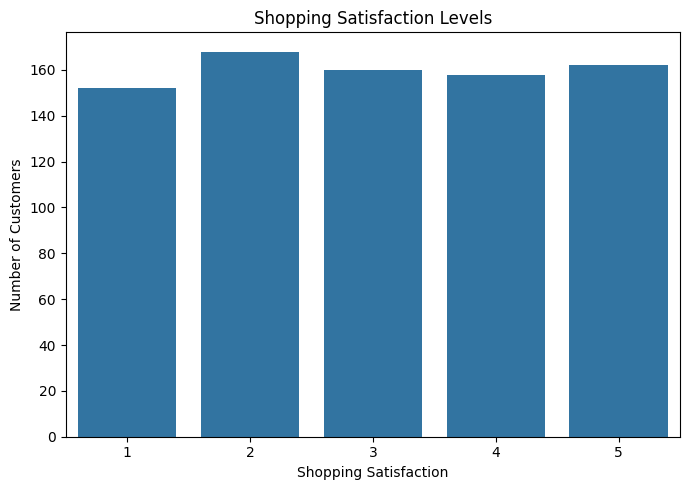

In [91]:
plt.figure(figsize=(7,5))

sns.countplot(
    x="Shopping_Satisfaction",
    data=df
)

plt.title("Shopping Satisfaction Levels")
plt.xlabel("Shopping Satisfaction")
plt.ylabel("Number of Customers")

plt.tight_layout()

plt.savefig(
    "Images/shopping_satisfaction_levels.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

##### Observation
- Shopping satisfaction ratings are evenly distributed between 1 and 5.
- No single satisfaction level dominates the dataset.
- Overall customer satisfaction appears to be balanced.

### Correlation between Recommendation Helpfulness and Shopping Satisfaction

In [92]:
recommendation_satisfaction = pd.crosstab(
    df["Recommendation_Helpfulness"],
    df["Shopping_Satisfaction"]
)

recommendation_satisfaction

Shopping_Satisfaction,1,2,3,4,5
Recommendation_Helpfulness,,,,,
No,49,52,52,57,52
Sometimes,57,55,52,51,53
Yes,46,61,56,50,57


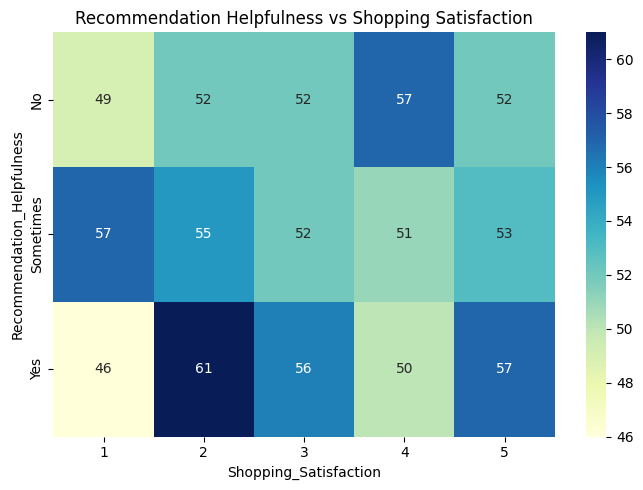

In [93]:
plt.figure(figsize=(7,5))

sns.heatmap(
    recommendation_satisfaction,
    annot=True,
    cmap="YlGnBu",
    fmt="d"
)

plt.title("Recommendation Helpfulness vs Shopping Satisfaction")

plt.tight_layout()

plt.savefig(
    "Images/recommendation_satisfaction_heatmap.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

#### Observation
- Recommendation helpfulness responses are distributed across all shopping satisfaction levels.
- No strong concentration is observed for any single combination.
- The relationship indicates that recommendation helpfulness alone does not determine customer satisfaction.

### Summary

The visualizations provide valuable insights into customer shopping behavior and preferences.

**Key Findings**

- Clothing and Fashion is the most popular purchase category among customers.
- Customer browsing behavior is distributed across different browsing frequencies, indicating varied shopping habits.
- Shopping satisfaction ratings are relatively balanced across all rating levels.
- Recommendation helpfulness and shopping satisfaction show a fairly balanced relationship, with customers reporting different satisfaction levels regardless of recommendation usefulness.
- These visualizations help businesses better understand customer behavior and support data-driven decision-making.